In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [3]:
os.getcwd()

'C:\\Users\\gokhan\\anaconda_projects\\JupyterProjects'

In [4]:
df = pd.read_csv("Algerian_forest_fires_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [6]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [7]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire
246,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire


In [8]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,246,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,33,5,2,20,63,19,40,174,167,199,107,175,127,9
top,1,7,2012,35,55,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,244,29,10,43,133,8,5,5,8,5,12,131


In [9]:
df.columns


Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [11]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [12]:
df[df["day"].isnull()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [14]:
df.drop(122,inplace = True)

In [15]:
df[df.isnull().any(axis=1)]


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [16]:
df.loc[:123,"Region"] = 0
df.loc[123:,"Region"] = 1

In [17]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0


In [18]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [19]:
df.drop(123,inplace = True)

In [20]:
df.columns = df.columns.str.strip()

In [21]:
df.loc[168, "Classes"] = "fire"

In [22]:
df = df.iloc[:, :-1]

In [23]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [24]:
df.loc[168]

day                 14
month                7
year              2012
Temperature         37
RH                  37
Ws                  18
Rain               0.2
FFMC              88.9
DMC               12.9
DC              14.6 9
ISI               12.5
BUI               10.4
FWI            fire   
Classes           fire
Name: 168, dtype: object

In [25]:
df["FWI"].values

array(['0.5', '0.4', '0.1', '0', '0.5', '2.5', '7.2', '7.1', '0.3', '0.9',
       '5.6', '7.1', '0.2', '0.4', '0.1', '0', '0', '0.2', '1.4', '0.4',
       '2.2', '2.3', '3.8', '7.5', '8.4', '10.6', '15', '13.9', '3.9',
       '12.9', '0.4', '0.3', '0.5', '1.7', '4.9', '6.8', '3.2', '8',
       '0.6', '0.5', '2.2', '0.9', '3.4', '0.8', '0.5', '0.4', '3.6', '6',
       '10.9', '4', '8.8', '2.8', '2.1', '1.3', '7.3', '15.3', '15.3',
       '11.3', '11.9', '10.7', '15.7', '0.9', '0.8', '0.8', '3.9', '6.1',
       '6.8', '8', '2.6', '9.9', '11.6', '12.1', '4.2', '10.2', '10.6',
       '6.3', '4.2', '14.6', '16.1', '17.2', '16.8', '18.4', '20.4',
       '22.3', '20.9', '20.3', '13.7', '13.2', '19.9', '30.2', '4.2',
       '0.3', '0.1', '0', '0', '0.5', '1.7', '0.9', '0.6', '0.4', '0.2',
       '0.3', '0.3', '0.5', '0', '0.1', '0', '0.8', '5.9', '7.7', '9.7',
       '6.3', '8.3', '2.8', '0.7', '0.7', '0.1', '1.7', '4.1', '0.9',
       '0.1', '0.1', 'FWI', '0.2', '0.2', '0.1', '1', '0.9', '3.1

In [26]:
df[df["FWI"] == "FWI"]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
124,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [27]:
df.drop(124,inplace = True)

In [28]:
df["FWI"].values


array(['0.5', '0.4', '0.1', '0', '0.5', '2.5', '7.2', '7.1', '0.3', '0.9',
       '5.6', '7.1', '0.2', '0.4', '0.1', '0', '0', '0.2', '1.4', '0.4',
       '2.2', '2.3', '3.8', '7.5', '8.4', '10.6', '15', '13.9', '3.9',
       '12.9', '0.4', '0.3', '0.5', '1.7', '4.9', '6.8', '3.2', '8',
       '0.6', '0.5', '2.2', '0.9', '3.4', '0.8', '0.5', '0.4', '3.6', '6',
       '10.9', '4', '8.8', '2.8', '2.1', '1.3', '7.3', '15.3', '15.3',
       '11.3', '11.9', '10.7', '15.7', '0.9', '0.8', '0.8', '3.9', '6.1',
       '6.8', '8', '2.6', '9.9', '11.6', '12.1', '4.2', '10.2', '10.6',
       '6.3', '4.2', '14.6', '16.1', '17.2', '16.8', '18.4', '20.4',
       '22.3', '20.9', '20.3', '13.7', '13.2', '19.9', '30.2', '4.2',
       '0.3', '0.1', '0', '0', '0.5', '1.7', '0.9', '0.6', '0.4', '0.2',
       '0.3', '0.3', '0.5', '0', '0.1', '0', '0.8', '5.9', '7.7', '9.7',
       '6.3', '8.3', '2.8', '0.7', '0.7', '0.1', '1.7', '4.1', '0.9',
       '0.1', '0.1', '0.2', '0.2', '0.1', '1', '0.9', '3.1', '6',

In [29]:
df["FWI"] = pd.to_numeric(df["FWI"], errors='coerce')

In [30]:
df.loc[168, "FWI"] = df["FWI"].mean()

In [31]:
df.loc[168]

day                  14
month                 7
year               2012
Temperature          37
RH                   37
Ws                   18
Rain                0.2
FFMC               88.9
DMC                12.9
DC               14.6 9
ISI                12.5
BUI                10.4
FWI            7.035391
Classes            fire
Name: 168, dtype: object

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    object 
 1   month        244 non-null    object 
 2   year         244 non-null    object 
 3   Temperature  244 non-null    object 
 4   RH           244 non-null    object 
 5   Ws           244 non-null    object 
 6   Rain         244 non-null    object 
 7   FFMC         244 non-null    object 
 8   DMC          244 non-null    object 
 9   DC           244 non-null    object 
 10  ISI          244 non-null    object 
 11  BUI          244 non-null    object 
 12  FWI          244 non-null    float64
 13  Classes      244 non-null    object 
dtypes: float64(1), object(13)
memory usage: 36.7+ KB


In [33]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0.0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [34]:
df[["day","month","year","Temperature","RH","Ws"]] = df[["day","month","year","Temperature","RH","Ws"]].astype(int)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4   RH           244 non-null    int64  
 5   Ws           244 non-null    int64  
 6   Rain         244 non-null    object 
 7   FFMC         244 non-null    object 
 8   DMC          244 non-null    object 
 9   DC           244 non-null    object 
 10  ISI          244 non-null    object 
 11  BUI          244 non-null    object 
 12  FWI          244 non-null    float64
 13  Classes      244 non-null    object 
dtypes: float64(1), int64(6), object(7)
memory usage: 36.7+ KB


In [36]:
df[df["DC"]=="14.6 9"]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,7.035391,fire


In [37]:
df.loc[168, "DC"] = "14.69"

In [38]:
df.loc[168]

day                  14
month                 7
year               2012
Temperature          37
RH                   37
Ws                   18
Rain                0.2
FFMC               88.9
DMC                12.9
DC                14.69
ISI                12.5
BUI                10.4
FWI            7.035391
Classes            fire
Name: 168, dtype: object

In [39]:
df[["Rain","FFMC","DMC","DC","ISI","BUI","FWI"]] = df[["Rain","FFMC","DMC","DC","ISI","BUI","FWI"]].astype(float)


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4   RH           244 non-null    int64  
 5   Ws           244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          244 non-null    float64
 13  Classes      244 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 36.7+ KB


In [41]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
count,244.000000,244.000000,244.0,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,15.754098,7.500000,2012.0,32.172131,61.938525,15.504098,0.760656,77.887705,14.673361,49.288484,4.774180,16.664754,7.035391
std,8.825059,1.112961,0.0,3.633843,14.884200,2.810178,1.999406,14.337571,12.368039,47.619393,4.175318,14.204824,7.425242
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.075000,5.800000,13.275000,1.400000,6.000000,0.700000
50%,16.000000,7.500000,2012.0,32.000000,63.000000,15.000000,0.000000,83.500000,11.300000,33.100000,3.500000,12.250000,4.450000
75%,23.000000,8.000000,2012.0,35.000000,73.250000,17.000000,0.500000,88.300000,20.750000,68.150000,7.300000,22.525000,11.375000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000


In [42]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [43]:
df["Classes"].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'not fire     ', 'not fire    '], dtype=object)

In [44]:
df["Classes"] = df["Classes"].str.strip()

In [45]:
df["Classes"].unique()

array(['not fire', 'fire'], dtype=object)

In [46]:
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0,1)

In [47]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0


In [48]:
df["Classes"].value_counts()

Classes
1    138
0    106
Name: count, dtype: int64

In [49]:
df["Classes"].value_counts(normalize=True)

Classes
1    0.565574
0    0.434426
Name: proportion, dtype: float64

In [50]:
df.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
day,1.000000e+00,2.232788e-17,NaN,0.095772,-0.074209,0.047001,-0.112265,0.224032,0.491571,0.527930,0.177727,0.517229,0.350752,0.201784
month,2.232788e-17,1.000000e+00,NaN,-0.059017,-0.037884,-0.041447,0.035322,0.015577,0.068178,0.127669,0.061680,0.085822,0.082604,0.022333
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,9.577222e-02,-5.901677e-02,NaN,1.000000,-0.654443,-0.278132,-0.326786,0.677491,0.483105,0.370511,0.607551,0.455504,0.564599,0.518119
RH,-7.420934e-02,-3.788419e-02,NaN,-0.654443,1.000000,0.236084,0.222968,-0.645658,-0.405133,-0.220344,-0.690637,-0.348587,-0.577577,-0.435023
Ws,4.700086e-02,-4.144673e-02,NaN,-0.278132,0.236084,1.000000,0.170169,-0.163255,-0.001246,0.076253,0.015248,0.029756,0.032315,-0.066529
Rain,-1.122654e-01,3.532207e-02,NaN,-0.326786,0.222968,0.170169,1.000000,-0.544045,-0.288548,-0.296808,-0.347105,-0.299171,-0.324369,-0.379449
FFMC,2.240321e-01,1.557668e-02,NaN,0.677491,-0.645658,-0.163255,-0.544045,1.000000,0.602391,0.503919,0.739730,0.589652,0.690289,0.770114
DMC,4.915710e-01,6.817778e-02,NaN,0.483105,-0.405133,-0.001246,-0.288548,0.602391,1.000000,0.875362,0.674499,0.982073,0.875827,0.584188
DC,5.279300e-01,1.276691e-01,NaN,0.370511,-0.220344,0.076253,-0.296808,0.503919,0.875362,1.000000,0.498926,0.941906,0.738714,0.507132


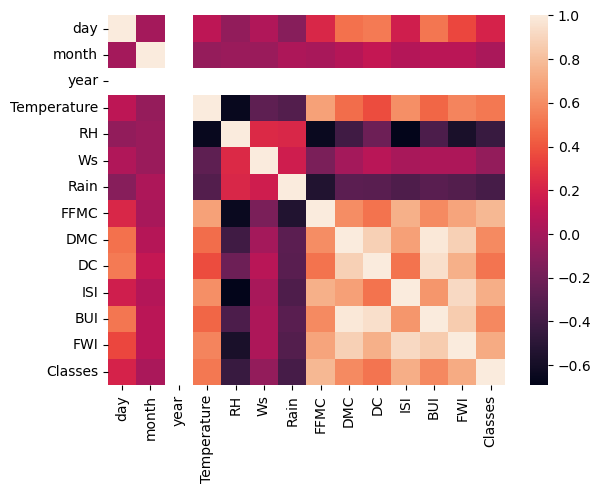

In [51]:
sns.heatmap(df.corr())
plt.show()

In [52]:
df.drop(["day","month","year"], axis=1, inplace=True)

In [53]:
#dependent and independent features

In [55]:
X = df.drop("FWI", axis = 1)
y = df["FWI"]

In [56]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0


In [57]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
242    6.5
243    0.0
244    0.2
245    0.7
246    0.5
Name: FWI, Length: 244, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=15)

In [61]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
Temperature,1.000000,-0.655010,-0.319583,-0.236366,0.615415,0.474671,0.361689,0.614550,0.444639,0.484037
RH,-0.655010,1.000000,0.239250,0.170720,-0.641715,-0.381933,-0.198008,-0.671938,-0.324071,-0.427245
Ws,-0.319583,0.239250,1.000000,0.158469,-0.150574,0.002822,0.097019,-0.008222,0.042318,-0.052280
Rain,-0.236366,0.170720,0.158469,1.000000,-0.477744,-0.263374,-0.284950,-0.337277,-0.276623,-0.365283
FFMC,0.615415,-0.641715,-0.150574,-0.477744,1.000000,0.591534,0.483820,0.747110,0.575099,0.770459
DMC,0.474671,-0.381933,0.002822,-0.263374,0.591534,1.000000,0.873922,0.665113,0.980660,0.548624
DC,0.361689,-0.198008,0.097019,-0.284950,0.483820,0.873922,1.000000,0.482395,0.940926,0.469391
ISI,0.614550,-0.671938,-0.008222,-0.337277,0.747110,0.665113,0.482395,1.000000,0.625087,0.732580
BUI,0.444639,-0.324071,0.042318,-0.276623,0.575099,0.980660,0.940926,0.625087,1.000000,0.548815
Classes,0.484037,-0.427245,-0.052280,-0.365283,0.770459,0.548624,0.469391,0.732580,0.548815,1.000000


In [62]:
#redundancy, multicolinearity, overfitting

In [66]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
Temperature,1.000000,-0.655010,-0.319583,-0.236366,0.615415,0.474671,0.361689,0.614550,0.444639,0.484037
RH,-0.655010,1.000000,0.239250,0.170720,-0.641715,-0.381933,-0.198008,-0.671938,-0.324071,-0.427245
Ws,-0.319583,0.239250,1.000000,0.158469,-0.150574,0.002822,0.097019,-0.008222,0.042318,-0.052280
Rain,-0.236366,0.170720,0.158469,1.000000,-0.477744,-0.263374,-0.284950,-0.337277,-0.276623,-0.365283
FFMC,0.615415,-0.641715,-0.150574,-0.477744,1.000000,0.591534,0.483820,0.747110,0.575099,0.770459
DMC,0.474671,-0.381933,0.002822,-0.263374,0.591534,1.000000,0.873922,0.665113,0.980660,0.548624
DC,0.361689,-0.198008,0.097019,-0.284950,0.483820,0.873922,1.000000,0.482395,0.940926,0.469391
ISI,0.614550,-0.671938,-0.008222,-0.337277,0.747110,0.665113,0.482395,1.000000,0.625087,0.732580
BUI,0.444639,-0.324071,0.042318,-0.276623,0.575099,0.980660,0.940926,0.625087,1.000000,0.548815
Classes,0.484037,-0.427245,-0.052280,-0.365283,0.770459,0.548624,0.469391,0.732580,0.548815,1.000000


In [67]:
print(X_train.corr().iloc[0,0])

1.0


In [68]:
def correlation_for_dropping(df,treshold):
    columns_to_drop = set()
    corr = X_train.corr()
    a = X_train.columns
    for i in range(len(a)):
        for j in range(i):
            if abs(corr.iloc[i,j])>treshold:
                columns_to_drop.add(corr.columns[i])
                
    return columns_to_drop            

In [71]:
columns_dropping = correlation_for_dropping(X_train,0.85)

In [72]:
columns_dropping

{'BUI', 'DC'}

In [73]:
X_train.drop(columns_dropping,axis=1,inplace=True)

In [74]:
X_test.drop(columns_dropping,axis=1,inplace=True)

In [76]:
X_train.shape

(183, 8)

In [77]:
X_test.shape

(61, 8)

In [78]:
from sklearn.preprocessing import StandardScaler

In [81]:
scaler = StandardScaler()

In [82]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

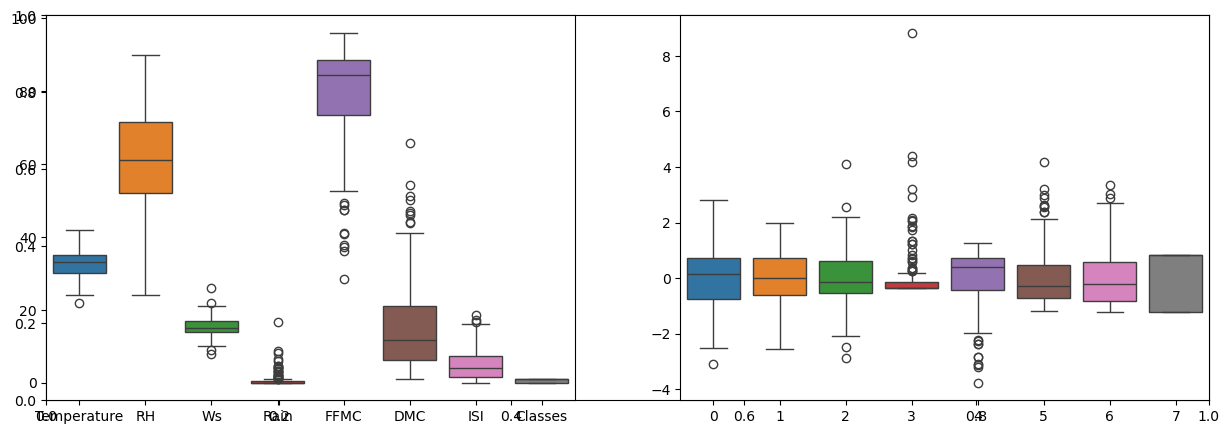

In [85]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.show()

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [89]:
linear = LinearRegression()

In [90]:
linear.fit(X_train_scaled,y_train)

LinearRegression()

In [91]:
y_pred = linear.predict(X_test_scaled)

Mean Absolute Error:  1.2599273669284803
Mean Squared Error:  3.9929661494716195
R2 Score:  0.9277768934205146


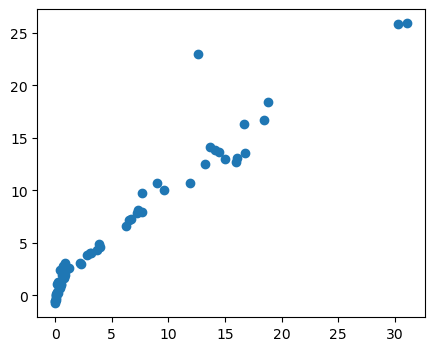

In [99]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error:  1.2599273669284803
Mean Squared Error:  3.9929661494716195
R2 Score:  0.9277768934205146


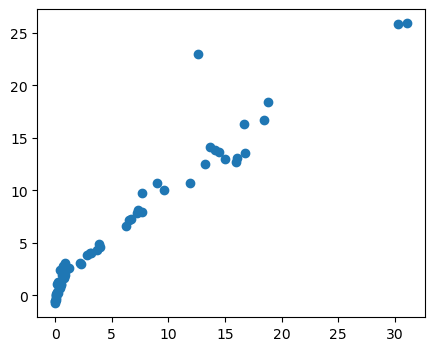

In [100]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error:  0.9149429261961354
Mean Squared Error:  4.081854720685859
R2 Score:  0.9261691140123787


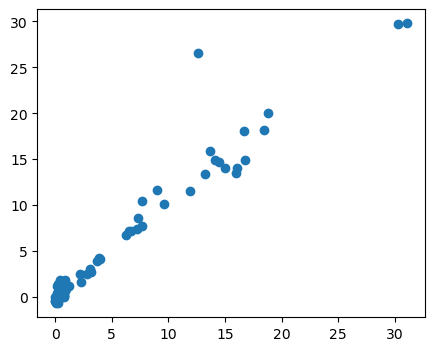

In [101]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error:  1.818339569412227
Mean Squared Error:  5.965994986431551
R2 Score:  0.8920895706028614


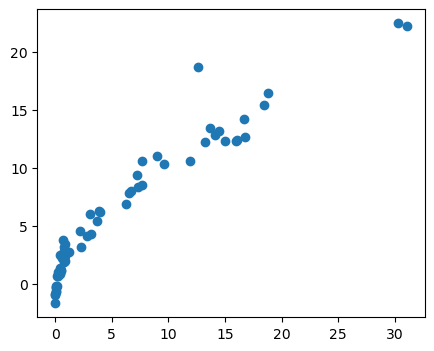

In [102]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

In [103]:
#Cross Validation

In [104]:
from sklearn.linear_model import LassoCV

Mean Absolute Error:  0.9069182543587745
Mean Squared Error:  4.140643925940435
R2 Score:  0.9251057593837936


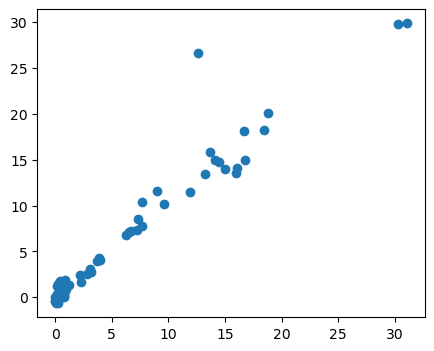

In [108]:
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

In [109]:
print("Lasso Katsayıları  :", lasso.coef_)
print("LassoCV Katsayıları:", lassocv.coef_)

Lasso Katsayıları  : [ 0.         -0.          0.         -0.          0.          2.77632296
  3.9668456   0.        ]
LassoCV Katsayıları: [-0.09859553  0.2071367  -0.02472595 -0.04428392 -0.78158805  3.45743095
  5.05655286  0.2987388 ]


In [112]:
print(lassocv.alpha_)

0.006813413301320666


In [111]:
lassocv.alphas_

array([6.8134133 , 6.35421205, 5.92595942, 5.52656959, 5.1540973 ,
       4.80672839, 4.48277098, 4.18064722, 3.89888559, 3.63611375,
       3.39105186, 3.16250631, 2.94936397, 2.75058671, 2.56520637,
       2.39232005, 2.23108568, 2.08071797, 1.94048455, 1.80970238,
       1.6877345 , 1.57398684, 1.4679054 , 1.36897349, 1.27670926,
       1.19066332, 1.1104166 , 1.03557824, 0.96578373, 0.90069314,
       0.83998944, 0.78337696, 0.73057998, 0.68134133, 0.6354212 ,
       0.59259594, 0.55265696, 0.51540973, 0.48067284, 0.4482771 ,
       0.41806472, 0.38988856, 0.36361138, 0.33910519, 0.31625063,
       0.2949364 , 0.27505867, 0.25652064, 0.239232  , 0.22310857,
       0.2080718 , 0.19404845, 0.18097024, 0.16877345, 0.15739868,
       0.14679054, 0.13689735, 0.12767093, 0.11906633, 0.11104166,
       0.10355782, 0.09657837, 0.09006931, 0.08399894, 0.0783377 ,
       0.073058  , 0.06813413, 0.06354212, 0.05925959, 0.0552657 ,
       0.05154097, 0.04806728, 0.04482771, 0.04180647, 0.03898

In [113]:
from sklearn.linear_model import RidgeCV

Mean Absolute Error:  0.9149429261961354
Mean Squared Error:  4.081854720685859
R2 Score:  0.9261691140123787


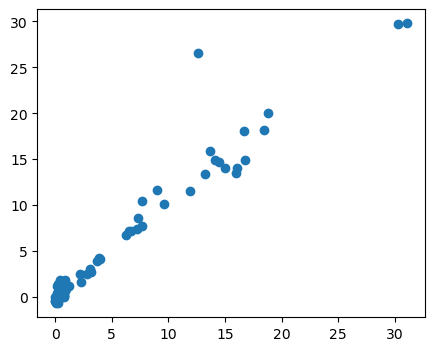

In [114]:
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

In [115]:
from sklearn.linear_model import ElasticNetCV

Mean Absolute Error:  0.915063416180178
Mean Squared Error:  4.019623098292975
R2 Score:  0.9272947336466174


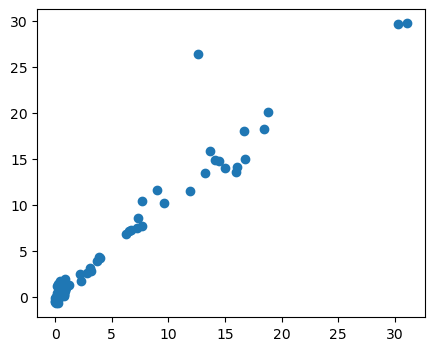

In [116]:
elasticcv = ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred = elasticcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()

In [122]:
!pip install lazypredict

In [128]:
from lazypredict.Supervised import LazyRegressor

In [129]:
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

GammaRegressor model failed to execute: Some value(s) of y are out of the valid range of the loss 'HalfGammaLoss'.
C:\Users\gokhan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\gokhan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\gokhan\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\gokhan\anaconda3\Lib\subprocess.py", line 1039, in __

In [130]:
print(models)

                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
ExtraTreesRegressor                      0.977317   0.980341  1.042523   
GradientBoostingRegressor                0.974824   0.978181  1.098328   
DecisionTreeRegressor                    0.970867   0.974752  1.181483   
RandomForestRegressor                    0.965369   0.969986  1.288156   
BaggingRegressor                         0.960907   0.966120  1.368623   
HistGradientBoostingRegressor            0.952986   0.959254  1.500898   
AdaBoostRegressor                        0.949117   0.955901  1.561431   
MLPRegressor                             0.941142   0.948990  1.679340   
KNeighborsRegressor                      0.932576   0.941566  1.797397   
SGDRegressor                             0.917315   0.928339  1.990445   
Lasso                                    0.916666   0.927777  1.998241   
LassoLars                             

In [131]:
from sklearn.ensemble import ExtraTreesRegressor


Mean Absolute Error:  0.5725765364636041
Mean Squared Error:  1.230172568341544
R2 Score:  0.9777491515859088


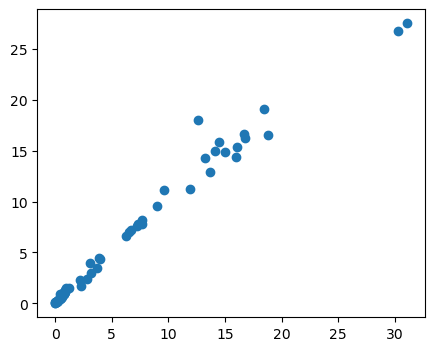

In [133]:
reg = ExtraTreesRegressor(n_estimators=100, random_state=0).fit(
   X_train, y_train)
y_pred = reg.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.figure(figsize=(5,4))
plt.scatter(y_test,y_pred)
plt.show()